In [1]:
import pandas as pd

# Load the cleaned CBE reviews CSV
boa_df = pd.read_csv("../data/processed/bank_of_abyssinia_cleaned_reviews.csv")

# Display basic info and first few rows
print("Shape:", boa_df.shape)
print(boa_df.columns)
boa_df.head()


Shape: (491, 5)
Index(['review', 'rating', 'date', 'bank', 'source'], dtype='object')


,review,rating,date,bank,source
0,"Hello, I’m facing a problem with the BOA Mobil...",1,2025-06-03,Bank of Abyssinia,Google Play
1,this is worest app 24/7 loading,1,2025-06-01,Bank of Abyssinia,Google Play
2,This App is not interest for Android phone Ple...,1,2025-06-01,Bank of Abyssinia,Google Play
3,BoA system is confartable,5,2025-06-01,Bank of Abyssinia,Google Play
4,"this app, for me , is a waste of time. It does...",1,2025-05-27,Bank of Abyssinia,Google Play


In [2]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary resources (only needed once)
nltk.download('punkt')
nltk.download('stopwords')

# Define stopwords
stop_words = set(stopwords.words('english'))

# Define a preprocessing function
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove digits and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(filtered_tokens)

# Apply preprocessing to a new column
boa_df['cleaned_review'] = boa_df['review'].astype(str).apply(preprocess_text)

# Preview
boa_df[['review', 'cleaned_review']].head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,cleaned_review
0,it's not working,working
1,"Hello, I’m facing a problem with the BOA Mobil...",hello facing problem boa mobile app every time...
2,exceptional,exceptional
3,BoA Mobile good bank,boa mobile good bank
4,this is worest app 24/7 loading,worest app loading


In [3]:

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import string

# Combine stopwords from nltk and punctuation
stop_words = set(stopwords.words('english') + list(string.punctuation))

# Define a preprocessing function for TF-IDF
def preprocess_text(text):
    tokens = text.lower().split()
    tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    return ' '.join(tokens)

# Apply preprocessing
boa_df['clean_review'] = boa_df['review'].astype(str).apply(preprocess_text)

# Run TF-IDF
vectorizer = TfidfVectorizer(max_features=30, ngram_range=(1, 2))
X = vectorizer.fit_transform(boa_df['clean_review'])

# Extract top TF-IDF keywords
tfidf_keywords = vectorizer.get_feature_names_out()
print("Top TF-IDF Keywords:")
print(tfidf_keywords)


Top TF-IDF Keywords:
['always' 'app' 'application' 'bank' 'banking' 'best' 'boa' 'crashes'
 'developer' 'even' 'ever' 'fix' 'good' 'keeps' 'like' 'make' 'mobile'
 'mobile banking' 'money' 'need' 'one' 'please' 'slow' 'time' 'update'
 'use' 'using' 'work' 'working' 'worst']


In [4]:
import spacy
from collections import Counter

# Load English spaCy model
nlp = spacy.load("en_core_web_sm")

# Function to extract noun chunks
def extract_noun_chunks(text):
    doc = nlp(text)
    return [chunk.text.lower() for chunk in doc.noun_chunks if len(chunk.text.split()) > 1]

# Apply to all reviews
boa_df['noun_chunks'] = boa_df['review'].astype(str).apply(extract_noun_chunks)

# Flatten and count most common noun chunks
all_chunks = [chunk for sublist in boa_df['noun_chunks'] for chunk in sublist]
chunk_counts = Counter(all_chunks)
top_chunks = chunk_counts.most_common(20)

print("Top Noun Phrases (spaCy):")
for phrase, count in top_chunks:
    print(f"{phrase}: {count}")


Top Noun Phrases (spaCy):
the app: 69
this app: 61
the bank: 13
developer options: 9
my phone: 8
this bank: 8
your app: 8
the application: 7
developer option: 7
worst app: 6
mobile banking: 6
a lot: 6
my account: 5
this application: 5
an app: 5
good app: 5
the worst mobile banking app: 5
you guys: 5
the developer options: 5
the time: 5


In [11]:
# Define themes and their keywords
themes = {
    "Login Issues": ["login", "sign in", "account access", "password"],
    "Transaction Problems": ["transfer", "transaction", "delay", "failed", "crash"],
    "App Usability": ["interface", "user friendly", "app design", "easy to use"],
    "Customer Support": ["support", "help", "contact"],
    "Positive Feedback": ["great", "good", "excellent", "love", "smooth", "helpful"]
}

# Function to assign themes to a review
def identify_themes(text):
    found_themes = []
    for theme, keywords in themes.items():
        for keyword in keywords:
            if keyword in text.lower():
                found_themes.append(theme)
                break  # avoid duplicate theme assignment
    return found_themes if found_themes else ["Other"]

# Apply function
boa_df['themes'] = boa_df['review'].astype(str).apply(identify_themes)

# Show sample
boa_df[['review', 'themes']].head(10)


,review,themes
0,"Hello, I’m facing a problem with the BOA Mobil...","[Login Issues, Transaction Problems]"
1,this is worest app 24/7 loading,[Other]
2,This App is not interest for Android phone Ple...,[Other]
3,BoA system is confartable,[Other]
4,"this app, for me , is a waste of time. It does...",[Other]
5,Good service.,[Positive Feedback]
6,the app crush frequently,[Other]
7,This app is a joke. It crashes more than it wo...,[Transaction Problems]
8,BoA,[Other]
9,but not opening on android,[Other]


In [13]:
print(boa_df.columns)

Index(['review', 'rating', 'date', 'bank', 'source', 'clean_review',
       'noun_chunks', 'sentiment', 'sentiment_score', 'themes'],
      dtype='object')


C:\Users\PC\AppData\Local\Temp\ipykernel_19796\1859400228.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=theme_df, x='count', y='theme', palette='viridis')


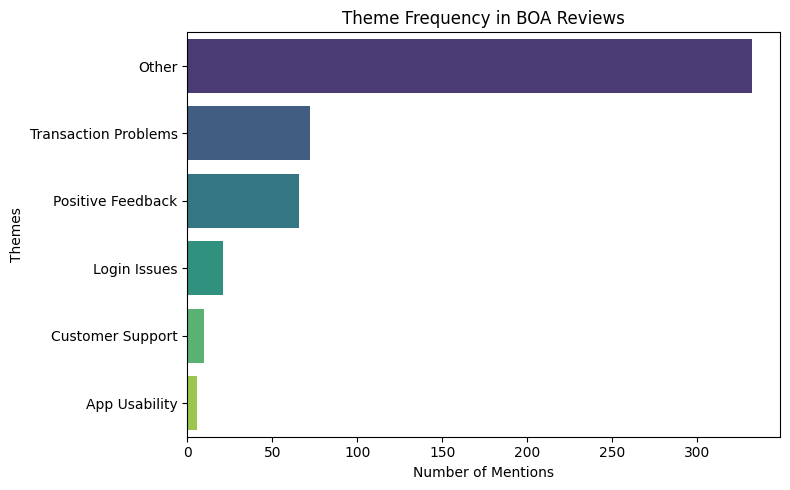

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Flatten all themes into a single list
all_themes = [theme for sublist in boa_df['themes'] for theme in sublist]
theme_counts = Counter(all_themes)

# Convert to DataFrame
theme_df = pd.DataFrame.from_dict(theme_counts, orient='index', columns=['count']).reset_index()
theme_df.columns = ['theme', 'count']
theme_df = theme_df.sort_values(by='count', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=theme_df, x='count', y='theme', palette='viridis')
plt.title("Theme Frequency in BOA Reviews")
plt.xlabel("Number of Mentions")
plt.ylabel("Themes")
plt.tight_layout()
plt.show()


In [15]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

# Initialize VADER
sid = SentimentIntensityAnalyzer()

# Analyze sentiment for each review
sentiment_labels = []
sentiment_scores = []

for review in tqdm(boa_df['review']):
    score = sid.polarity_scores(str(review))['compound']
    sentiment_scores.append(score)

    if score >= 0.05:
        sentiment_labels.append('positive')
    elif score <= -0.05:
        sentiment_labels.append('negative')
    else:
        sentiment_labels.append('neutral')

# Create sentiment_results DataFrame
sentiment_results = pd.DataFrame({
    'sentiment': sentiment_labels,
    'sentiment_score': sentiment_scores
})

# Attach it to cbe_df
boa_df = boa_df.reset_index(drop=True)
sentiment_results = sentiment_results.reset_index(drop=True)

boa_df['sentiment'] = sentiment_results['sentiment']
boa_df['sentiment_score'] = sentiment_results['sentiment_score']

print("✅ Sentiment scores added!")


  0%|          | 0/491 [00:00<?, ?it/s]

✅ Sentiment scores added!


In [16]:
# Select columns to save
final_df = boa_df[['review', 'rating', 'date', 'sentiment', 'sentiment_score', 'themes']]

# Save to CSV
final_df.to_csv("boa_sentiment_themes.csv", index=False)

print("✅ Saved to boa_sentiment_themes.csv")


✅ Saved to boa_sentiment_themes.csv


In [10]:
print(cbe_df.columns)

Index(['review', 'rating', 'date', 'bank', 'source', 'cleaned_review',
       'clean_review', 'noun_chunks', 'themes', 'sentiment',
       'sentiment_score'],
      dtype='object')


In [11]:
# Ensure sentiment_results exists and matches cbe_df
cbe_df = cbe_df.reset_index(drop=True)
sentiment_results = sentiment_results.reset_index(drop=True)

# Add the sentiment and score columns to cbe_df
cbe_df['sentiment'] = sentiment_results['sentiment']
cbe_df['sentiment_score'] = sentiment_results['sentiment_score']


In [27]:
# Save processed CBE data with sentiment and themes
output_path = "processed_boa_data_with_sentiment_reviews.csv"
boa_df.to_csv(output_path, index=False)
print(f"✅ Data saved to {output_path}")



✅ Data saved to processed_boa_data_with_sentiment_reviews.csv
